# Movie Ratings Explorer

**A Comprehensive Analysis of IMDb's Top 1000 Movies**

**Author:** Visura Rodrigo  
**Dataset:** IMDb Top 1000 Movies (`imdb_top_1000.csv`)  
**Purpose:** Exploratory data analysis and SQL-based insights on movie ratings, genres, directors, and revenue trends

## Step 1: Environment Setup

Install and import all required libraries for data processing and visualization.

In [1]:
# Install required packages silently
import subprocess
import sys

packages = ['ipython-sql', 'prettytable==2.0.0', 'matplotlib', 'seaborn', 'pandas']
for package in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', package, '--quiet'])

In [2]:
# Load SQL magic extension for Jupyter
%load_ext sql

# Configure SQL display settings
%config SqlMagic.style = 'PLAIN_COLUMNS'

## Step 2: Data Ingestion & SQLite Database Setup

Load the IMDb dataset from CSV and create a SQLite database for efficient querying.

In [3]:
# Import required libraries
from pathlib import Path
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set professional matplotlib styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

In [4]:
# Define portable data paths
raw_data_path = Path('../data/raw/imdb_top_1000.csv')
db_path = Path('../data/processed/movies.db')

# Ensure processed directory exists
db_path.parent.mkdir(parents=True, exist_ok=True)

# Load CSV into pandas DataFrame
df = pd.read_csv(raw_data_path, encoding='utf-8-sig')

print("✓ Dataset Loaded Successfully")
print(f"Shape: {df.shape[0]} movies × {df.shape[1]} columns\n")
print("Sample Data:")
display(df.head())

✓ Dataset Loaded Successfully
Shape: 1000 movies × 16 columns

Sample Data:


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [5]:
# Establish SQLite database connection
conn = sqlite3.connect(str(db_path))
print(f"Connected to database: {db_path.name}")

Connected to database: movies.db


In [6]:
# Define Movies table schema
create_table_query = '''
CREATE TABLE IF NOT EXISTS Movies (
    Series_Title TEXT PRIMARY KEY,
    Released_Year INTEGER,
    Genre TEXT,
    Director TEXT,
    IMDB_Rating REAL,
    No_of_Votes INTEGER,
    Gross REAL,
    Meta_score REAL
);
'''

# Clean previous table if it exists and recreate
conn.execute("DROP TABLE IF EXISTS Movies;")
conn.execute(create_table_query)
conn.commit()

print("Movies table created successfully")

Movies table created successfully


In [8]:
# Define columns to import into the database
columns_to_use = [
    'Series_Title', 'Released_Year', 'Genre', 'Director', 
    'IMDB_Rating', 'No_of_Votes', 'Gross', 'Meta_score'
]

# Prepare data: convert Gross from string to numeric and clean
df_prepared = df[columns_to_use].copy()
df_prepared['Gross'] = pd.to_numeric(df_prepared['Gross'].str.replace(',', ''), errors='coerce')
df_prepared['Released_Year'] = pd.to_numeric(df_prepared['Released_Year'], errors='coerce')

# Load data into SQLite (replace existing data to avoid constraint violation)
df_prepared.to_sql('Movies', conn, if_exists='replace', index=False)
print(f"{len(df_prepared)} movie records imported into SQLite")

1000 movie records imported into SQLite


In [9]:
# Maintain connection for subsequent SQL magic queries
print("Database ready for SQL analysis")

Database ready for SQL analysis


## Step 3: Connect SQL Magic to Database

Enable interactive SQL queries using Jupyter's SQL magic extension.

In [10]:
# Connect SQL magic to the SQLite database file
%sql sqlite:///../data/processed/movies.db

## Step 4: SQL-Based Exploratory Analysis

Execute targeted SQL queries to uncover key insights in the IMDb dataset.

In [11]:
# Query 1: Top 10 highest-rated movies in the dataset
print("\nTop 10 Highest Rated Movies")
print("=" * 70)
%sql SELECT Series_Title AS Title, Released_Year AS Year, IMDB_Rating AS Rating FROM Movies ORDER BY IMDB_Rating DESC LIMIT 10;


Top 10 Highest Rated Movies
 * sqlite:///../data/processed/movies.db
Done.


Title,Year,Rating
The Shawshank Redemption,1994.0,9.3
The Godfather,1972.0,9.2
The Dark Knight,2008.0,9.0
The Godfather: Part II,1974.0,9.0
12 Angry Men,1957.0,9.0
The Lord of the Rings: The Return of the King,2003.0,8.9
Pulp Fiction,1994.0,8.9
Schindler's List,1993.0,8.9
Inception,2010.0,8.8
Fight Club,1999.0,8.8


In [12]:
# Query 2: Distribution of movies across genres
print("\nMovie Distribution by Genre (Top 10)")
print("=" * 70)
%sql SELECT Genre, COUNT(*) AS MovieCount FROM Movies GROUP BY Genre ORDER BY MovieCount DESC LIMIT 10;


Movie Distribution by Genre (Top 10)
 * sqlite:///../data/processed/movies.db
Done.


Genre,MovieCount
Drama,85
"Drama, Romance",37
"Comedy, Drama",35
"Comedy, Drama, Romance",31
"Action, Crime, Drama",30
"Crime, Drama, Thriller",28
"Biography, Drama, History",28
"Crime, Drama, Mystery",27
"Crime, Drama",26
"Animation, Adventure, Comedy",24


In [13]:
# Query 3: Critically acclaimed recent releases (post-2010, rating > 8.0)
print("\nHighly Rated Movies Released After 2010 (IMDb Rating > 8.0)")
print("=" * 70)
%sql SELECT Series_Title AS Title, Released_Year AS Year, IMDB_Rating AS Rating FROM Movies WHERE Released_Year > 2010 AND IMDB_Rating > 8.0 ORDER BY IMDB_Rating DESC LIMIT 10;


Highly Rated Movies Released After 2010 (IMDb Rating > 8.0)
 * sqlite:///../data/processed/movies.db
Done.


Title,Year,Rating
Hamilton,2020.0,8.6
Gisaengchung,2019.0,8.6
Soorarai Pottru,2020.0,8.6
Interstellar,2014.0,8.6
Joker,2019.0,8.5
Whiplash,2014.0,8.5
The Intouchables,2011.0,8.5
Capharnaüm,2018.0,8.4
Ayla: The Daughter of War,2017.0,8.4
Vikram Vedha,2017.0,8.4


In [14]:
# Query 4: Most prolific directors in the dataset
print("\nTop 10 Most Prolific Directors")
print("=" * 70)
%sql SELECT Director, COUNT(*) AS NumberOfMovies FROM Movies GROUP BY Director ORDER BY NumberOfMovies DESC LIMIT 10;


Top 10 Most Prolific Directors
 * sqlite:///../data/processed/movies.db
Done.


Director,NumberOfMovies
Alfred Hitchcock,14
Steven Spielberg,13
Hayao Miyazaki,11
Martin Scorsese,10
Akira Kurosawa,10
Woody Allen,9
Stanley Kubrick,9
Billy Wilder,9
Quentin Tarantino,8
David Fincher,8


In [15]:
# Query 5: Genre-level performance metrics (rating and revenue)
print("\nGenre Performance Metrics (Average Rating & Revenue)")
print("=" * 70)
%sql SELECT Genre, ROUND(AVG(IMDB_Rating), 2) AS Avg_Rating, ROUND(AVG(Gross), 2) AS Avg_Revenue, COUNT(*) AS Movie_Count FROM Movies WHERE Gross IS NOT NULL GROUP BY Genre ORDER BY Avg_Rating DESC;


Genre Performance Metrics (Average Rating & Revenue)
 * sqlite:///../data/processed/movies.db
Done.


Genre,Avg_Rating,Avg_Revenue,Movie_Count
"Horror, Sci-Fi",8.4,78900000.0,1
"Crime, Mystery, Thriller",8.4,11685222.5,2
"Action, Sci-Fi",8.4,138241093.33,3
Western,8.35,14555377.0,4
"Drama, Mystery, War",8.35,45164303.5,2
"Mystery, Romance, Thriller",8.3,3200000.0,1
"Crime, Drama, Sci-Fi",8.3,6207725.0,1
"Crime, Drama, Music",8.3,1373943.0,1
"Comedy, Musical, Romance",8.3,8819028.0,1
"Adventure, Mystery, Thriller",8.3,13275000.0,1


In [16]:
# Query 6: Directors with highest average ratings (minimum 5 movies)
print("\nTop-Rated Directors (Minimum 5 Films)")
print("=" * 70)
%sql SELECT Director, ROUND(AVG(IMDB_Rating), 2) AS Avg_Rating, COUNT(*) AS Movie_Count FROM Movies GROUP BY Director HAVING Movie_Count >= 5 ORDER BY Avg_Rating DESC LIMIT 10;


Top-Rated Directors (Minimum 5 Films)
 * sqlite:///../data/processed/movies.db
Done.


Director,Avg_Rating,Movie_Count
Christopher Nolan,8.46,8
Peter Jackson,8.4,5
Francis Ford Coppola,8.4,5
Charles Chaplin,8.33,6
Sergio Leone,8.27,6
Stanley Kubrick,8.23,9
Akira Kurosawa,8.22,10
Quentin Tarantino,8.18,8
Martin Scorsese,8.17,10
Ingmar Bergman,8.14,7


## Step 5: Python-Based Visualizations

Create professional visualizations to communicate key insights from the data.

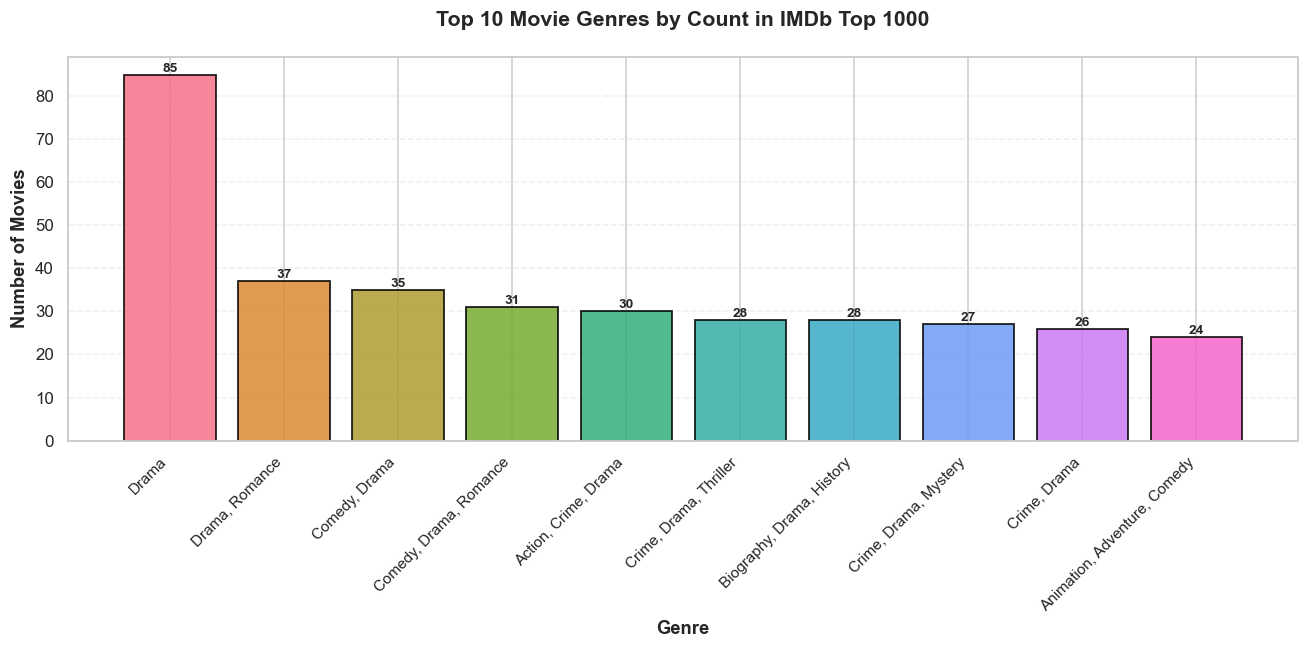

In [17]:
### Visualization 1: Genre Distribution

# Query genre data from database
genre_df = pd.read_sql_query('''
    SELECT Genre, COUNT(*) AS MovieCount
    FROM Movies
    GROUP BY Genre
    ORDER BY MovieCount DESC
    LIMIT 10;
''', conn)

# Create professional bar chart
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(
    range(len(genre_df)),
    genre_df['MovieCount'],
    color=sns.color_palette('husl', n_colors=len(genre_df)),
    alpha=0.85,
    edgecolor='black',
    linewidth=1.2
)

# Customize chart appearance
ax.set_xticks(range(len(genre_df)))
ax.set_xticklabels(genre_df['Genre'], rotation=45, ha='right', fontsize=10)
ax.set_xlabel('Genre', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Movies', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Movie Genres by Count in IMDb Top 1000', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

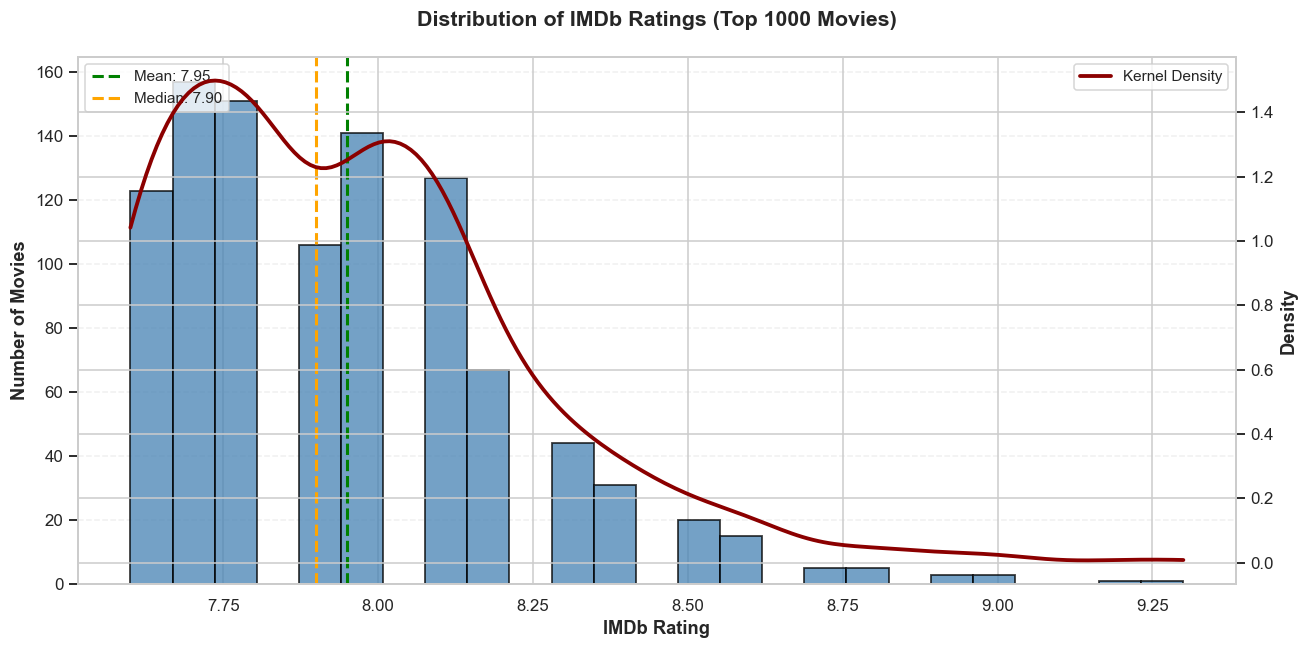

In [20]:
### Visualization 2: Distribution of IMDb Ratings

import numpy as np
from scipy import stats

# Create professional histogram with KDE
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(
    df['IMDB_Rating'],
    bins=25,
    color='steelblue',
    alpha=0.75,
    edgecolor='black',
    linewidth=1.2
)

# Add KDE curve
kde_xs = np.linspace(df['IMDB_Rating'].min(), df['IMDB_Rating'].max(), 200)
# Add KDE curve
from scipy import stats
kde_xs = np.linspace(df['IMDB_Rating'].min(), df['IMDB_Rating'].max(), 200)
kde = stats.gaussian_kde(df['IMDB_Rating'].dropna())
ax2 = ax.twinx()
ax2.plot(kde_xs, kde(kde_xs), color='darkred', linewidth=2.5, label='Kernel Density')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.legend(loc='upper right', fontsize=10)

# Customize appearance
ax.set_xlabel('IMDb Rating', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Movies', fontsize=12, fontweight='bold')
ax.set_title('Distribution of IMDb Ratings (Top 1000 Movies)', fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add statistics annotation
mean_rating = df['IMDB_Rating'].mean()
median_rating = df['IMDB_Rating'].median()
ax.axvline(mean_rating, color='green', linestyle='--', linewidth=2, label=f'Mean: {mean_rating:.2f}')
ax.axvline(median_rating, color='orange', linestyle='--', linewidth=2, label=f'Median: {median_rating:.2f}')
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

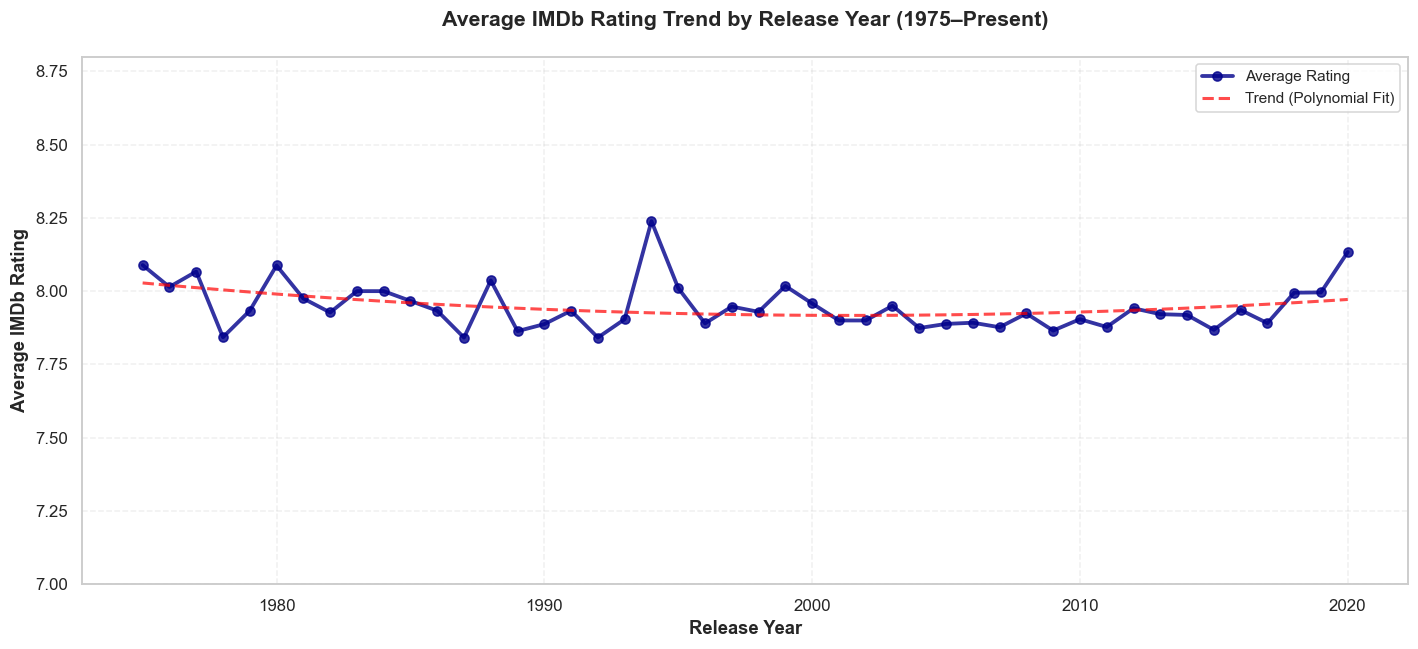

In [21]:
### Visualization 3: Average Rating Trend Over Time

import numpy as np

# Query average ratings by release year (last 50+ years)
rating_trend_df = pd.read_sql_query('''
    SELECT Released_Year, AVG(IMDB_Rating) AS AvgRating, COUNT(*) AS MovieCount
    FROM Movies
    WHERE Released_Year >= 1975
    GROUP BY Released_Year
    ORDER BY Released_Year;
''', conn)

# Clean data: ensure year is numeric
rating_trend_df['Released_Year'] = pd.to_numeric(rating_trend_df['Released_Year'], errors='coerce')
rating_trend_df = rating_trend_df.dropna(subset=['Released_Year']).sort_values('Released_Year')

# Create professional line chart with markers
fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(
    rating_trend_df['Released_Year'],
    rating_trend_df['AvgRating'],
    marker='o',
    linewidth=2.5,
    markersize=6,
    color='darkblue',
    alpha=0.8,
    label='Average Rating'
)

# Add trend line
z = np.polyfit(rating_trend_df['Released_Year'], rating_trend_df['AvgRating'], 2)
p = np.poly1d(z)
ax.plot(
    rating_trend_df['Released_Year'],
    p(rating_trend_df['Released_Year']),
    '--',
    color='red',
    linewidth=2,
    alpha=0.7,
    label='Trend (Polynomial Fit)'
)

# Customize appearance
ax.set_xlabel('Release Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Average IMDb Rating', fontsize=12, fontweight='bold')
ax.set_title('Average IMDb Rating Trend by Release Year (1975–Present)', fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best', fontsize=10)
ax.set_ylim(7.0, 8.8)

plt.tight_layout()
plt.show()